# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---
## 2. Load data

In [3]:
df = pd.read_csv('Data/data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


---

## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [12]:
#import sklearn
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [5]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm. 

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging. 

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

In [ ]:
# Add model training in here!
model = RandomForestClassifier(random_state=42, n_jobs=-1) # Add starter

parameters = { # Testing other parameters for gridsearch
    'max_depth': [2, 3, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100, 200],
    'n_estimators': [10, 25, 30, 50, 100, 200]
}

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=model, 
                           param_grid=parameters, 
                           cv=5, 
                           n_jobs=-1, verbose=1, scoring='accuracy')

grid_search.fit(X_train, y_train) # Complete this method call!

Fitting 5 folds for each of 180 candidates, totalling 900 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'min_samples_leaf': [5, 10, ...], 'n_estimators': [10, 25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_gr

In [9]:
grid_search.best_score_

np.float64(0.905057551752812)

In [10]:
model_best = grid_search.best_estimator_
model_best

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total nu

### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

In [ ]:
# Generate predictions here
predictions = model_best.predict(X_test)

In [16]:
# Calculate performance metrics here
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3286
           1       0.91      0.03      0.05       366

    accuracy                           0.90      3652
   macro avg       0.91      0.51      0.50      3652
weighted avg       0.90      0.90      0.86      3652

[[3285    1]
 [ 356   10]]


Recall is very low for the churn group showing that of the customers that churned, the model does not do well predicting them. The model was fooled due to the class imbalance showing a high accuracy. I'll do another round with more penalties for missed churners.

In [17]:
rf_balanced = RandomForestClassifier(
    max_depth=20, 
    min_samples_leaf=5, 
    n_estimators=30,
    class_weight='balanced', #this adjustment will change the weights inversely proportional to class frequencies
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)
predictions_balanced = rf_balanced.predict(X_test)
print(classification_report(y_test, predictions_balanced))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      3286
           1       0.23      0.28      0.25       366

    accuracy                           0.83      3652
   macro avg       0.57      0.59      0.58      3652
weighted avg       0.85      0.83      0.84      3652



Even with balanceed class weights, the recall on churning customers is very low. I will try SMOTE to generate examples of the churn class.

In [18]:
from imblearn.over_sampling import SMOTE

In [20]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model_smote = RandomForestClassifier(
    max_depth=20, 
    min_samples_leaf=5, 
    n_estimators=30,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_smote.fit(X_train_smote, y_train_smote)
predictions_smote = model_smote.predict(X_test)
print(classification_report(y_test, predictions_smote))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      3286
           1       0.37      0.08      0.13       366

    accuracy                           0.89      3652
   macro avg       0.64      0.53      0.54      3652
weighted avg       0.85      0.89      0.86      3652



SMOTE hurt the overall recall even with the balanced class weights. First I will try a new gridsearch with the SMOTE.



In [23]:
from imblearn.pipeline import Pipeline

In [24]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

params = {
    'rf__max_depth': [2, 3, 5, 10, 20],
    'rf__min_samples_leaf': [5, 10, 20, 50, 100, 200],
    'rf__n_estimators': [10, 25, 30, 50, 100, 200]
}

grid_search_smote = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    cv=4,
    n_jobs=-1,
    verbose=1,
    scoring='recall'
)

grid_search_smote.fit(X_train, y_train)
print(grid_search_smote.best_params_)

Fitting 4 folds for each of 180 candidates, totalling 720 fits
{'rf__max_depth': 2, 'rf__min_samples_leaf': 100, 'rf__n_estimators': 30}


In [26]:
model_smote = RandomForestClassifier(
    max_depth=2, 
    min_samples_leaf=100, 
    n_estimators=30,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_smote.fit(X_train_smote, y_train_smote)
predictions_smote = model_smote.predict(X_test)

print(classification_report(y_test, predictions_smote))

              precision    recall  f1-score   support

           0       0.91      0.68      0.78      3286
           1       0.13      0.42      0.20       366

    accuracy                           0.65      3652
   macro avg       0.52      0.55      0.49      3652
weighted avg       0.83      0.65      0.72      3652



In [28]:
# Applying a threshold to the predicted probabilities
probabilities = grid_search_smote.best_estimator_.predict_proba(X_test)[:, 1]

for threshold in [0.6, 0.55, 0.5, 0.4]:
    predictions = (probabilities >= threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, predictions))


Threshold: 0.6
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      3286
           1       0.17      0.02      0.03       366

    accuracy                           0.89      3652
   macro avg       0.53      0.50      0.49      3652
weighted avg       0.83      0.89      0.85      3652


Threshold: 0.55
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      3286
           1       0.15      0.22      0.18       366

    accuracy                           0.79      3652
   macro avg       0.53      0.54      0.53      3652
weighted avg       0.83      0.79      0.81      3652


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.91      0.66      0.76      3286
           1       0.12      0.42      0.19       366

    accuracy                           0.63      3652
   macro avg       0.52      0.54      0.47      3652
weighted avg       0.83  

The best looking threshold is 0.5 with a recall of 0.42, but that drops the precision to 0.12 and the accuracy to 0.63

I am going to try and go back to the original best model and change the decision threshold.

In [21]:
probabilities = model_best.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.2, 0.15, 0.1]:
    predictions = (probabilities >= threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, predictions))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3286
           1       0.91      0.03      0.05       366

    accuracy                           0.90      3652
   macro avg       0.91      0.51      0.50      3652
weighted avg       0.90      0.90      0.86      3652


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3286
           1       0.94      0.04      0.08       366

    accuracy                           0.90      3652
   macro avg       0.92      0.52      0.52      3652
weighted avg       0.91      0.90      0.86      3652


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      3286
           1       0.47      0.10      0.16       366

    accuracy                           0.90      3652
   macro avg       0.69      0.54      0.55      3652
weighted avg       0.86   

None of the different thresholds are great, so I will go back and look at feature importances before making a change.

In [22]:
importances = pd.Series(model_best.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(15)

margin_net_pow_ele                 0.058169
margin_gross_pow_ele               0.051499
cons_12m                           0.049797
net_margin                         0.049040
forecast_meter_rent_12m            0.044427
forecast_cons_12m                  0.040352
cons_last_month                    0.040160
pow_max                            0.036722
months_activ                       0.033578
var_year_price_off_peak_var        0.031527
months_modif_prod                  0.030505
off_peak_mid_peak_var_mean_diff    0.029812
imp_cons                           0.029301
off_peak_peak_var_mean_diff        0.029065
offpeak_diff_dec_january_energy    0.028250
dtype: float64

Looking at the feature importance values, I notice that there is not a few features dominating the predeictions. However, since they are all spread out, there is not a strong signal for prediction. One good note is that the engineered features of price differences are showing up and adding value. As far as the recall problem, I believe that the problem is the severe class imbalance. 

## Conclution

After looking through both balanced classes and SMOTE techniques, I have come up with the best candidates from each:



In [29]:
results = {
    'Model': ['Original @ 0.15', 'SMOTE @ 0.5'],
    'Churn Recall': [0.41, 0.42],
    'Churn Precision': [0.19, 0.12],
    'Accuracy': [0.77, 0.63]
}

comparison_df = pd.DataFrame(results)
print(comparison_df)

             Model  Churn Recall  Churn Precision  Accuracy
0  Original @ 0.15          0.41             0.19      0.77
1      SMOTE @ 0.5          0.42             0.12      0.63


### Terminology Meaning:

Recall: Of all customers who actually churned, what percentage did the model catch?
High recall means fewer churners slipping through undetected.

Precision: Of all customers the model flagged as churners, what percentage actually churned?
High precision means fewer wasted retention efforts on customers who weren't leaving.

Accuracy: Of all predictions made, what percentage were correct across both classes?
Less meaningful here due to class imbalance - a model that never predicts
churn would still score ~90% accuracy since 90% of customers don't churn.

### Final Model:

Final Model: RandomForestClassifier with threshold of 0.15
----------------------------------------------------------
I selected the original grid search model (model_best) with a lowered decision
threshold of 0.15 as our final model. The default threshold of 0.5 was too
conservative for churn prediction, catching only 3% of actual churners.

Lowering the threshold to 0.15 means we predict churn whenever the model assigns
at least a 15% probability of churning, rather than the default 50%. This increased
churn recall from 0.03 to 0.41 at the cost of some precision and overall accuracy.

I also tested SMOTE (synthetic oversampling of the minority class) to address the
class imbalance (3286 non-churners vs 366 churners), but it produced comparable
recall with lower precision and accuracy, so the simpler model was preferred.

In [30]:
final_probabilities = model_best.predict_proba(X_test)[:, 1]
final_predictions = (final_probabilities >= 0.15).astype(int)
print(classification_report(y_test, final_predictions))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86      3286
           1       0.19      0.41      0.26       366

    accuracy                           0.77      3652
   macro avg       0.56      0.61      0.56      3652
weighted avg       0.85      0.77      0.80      3652



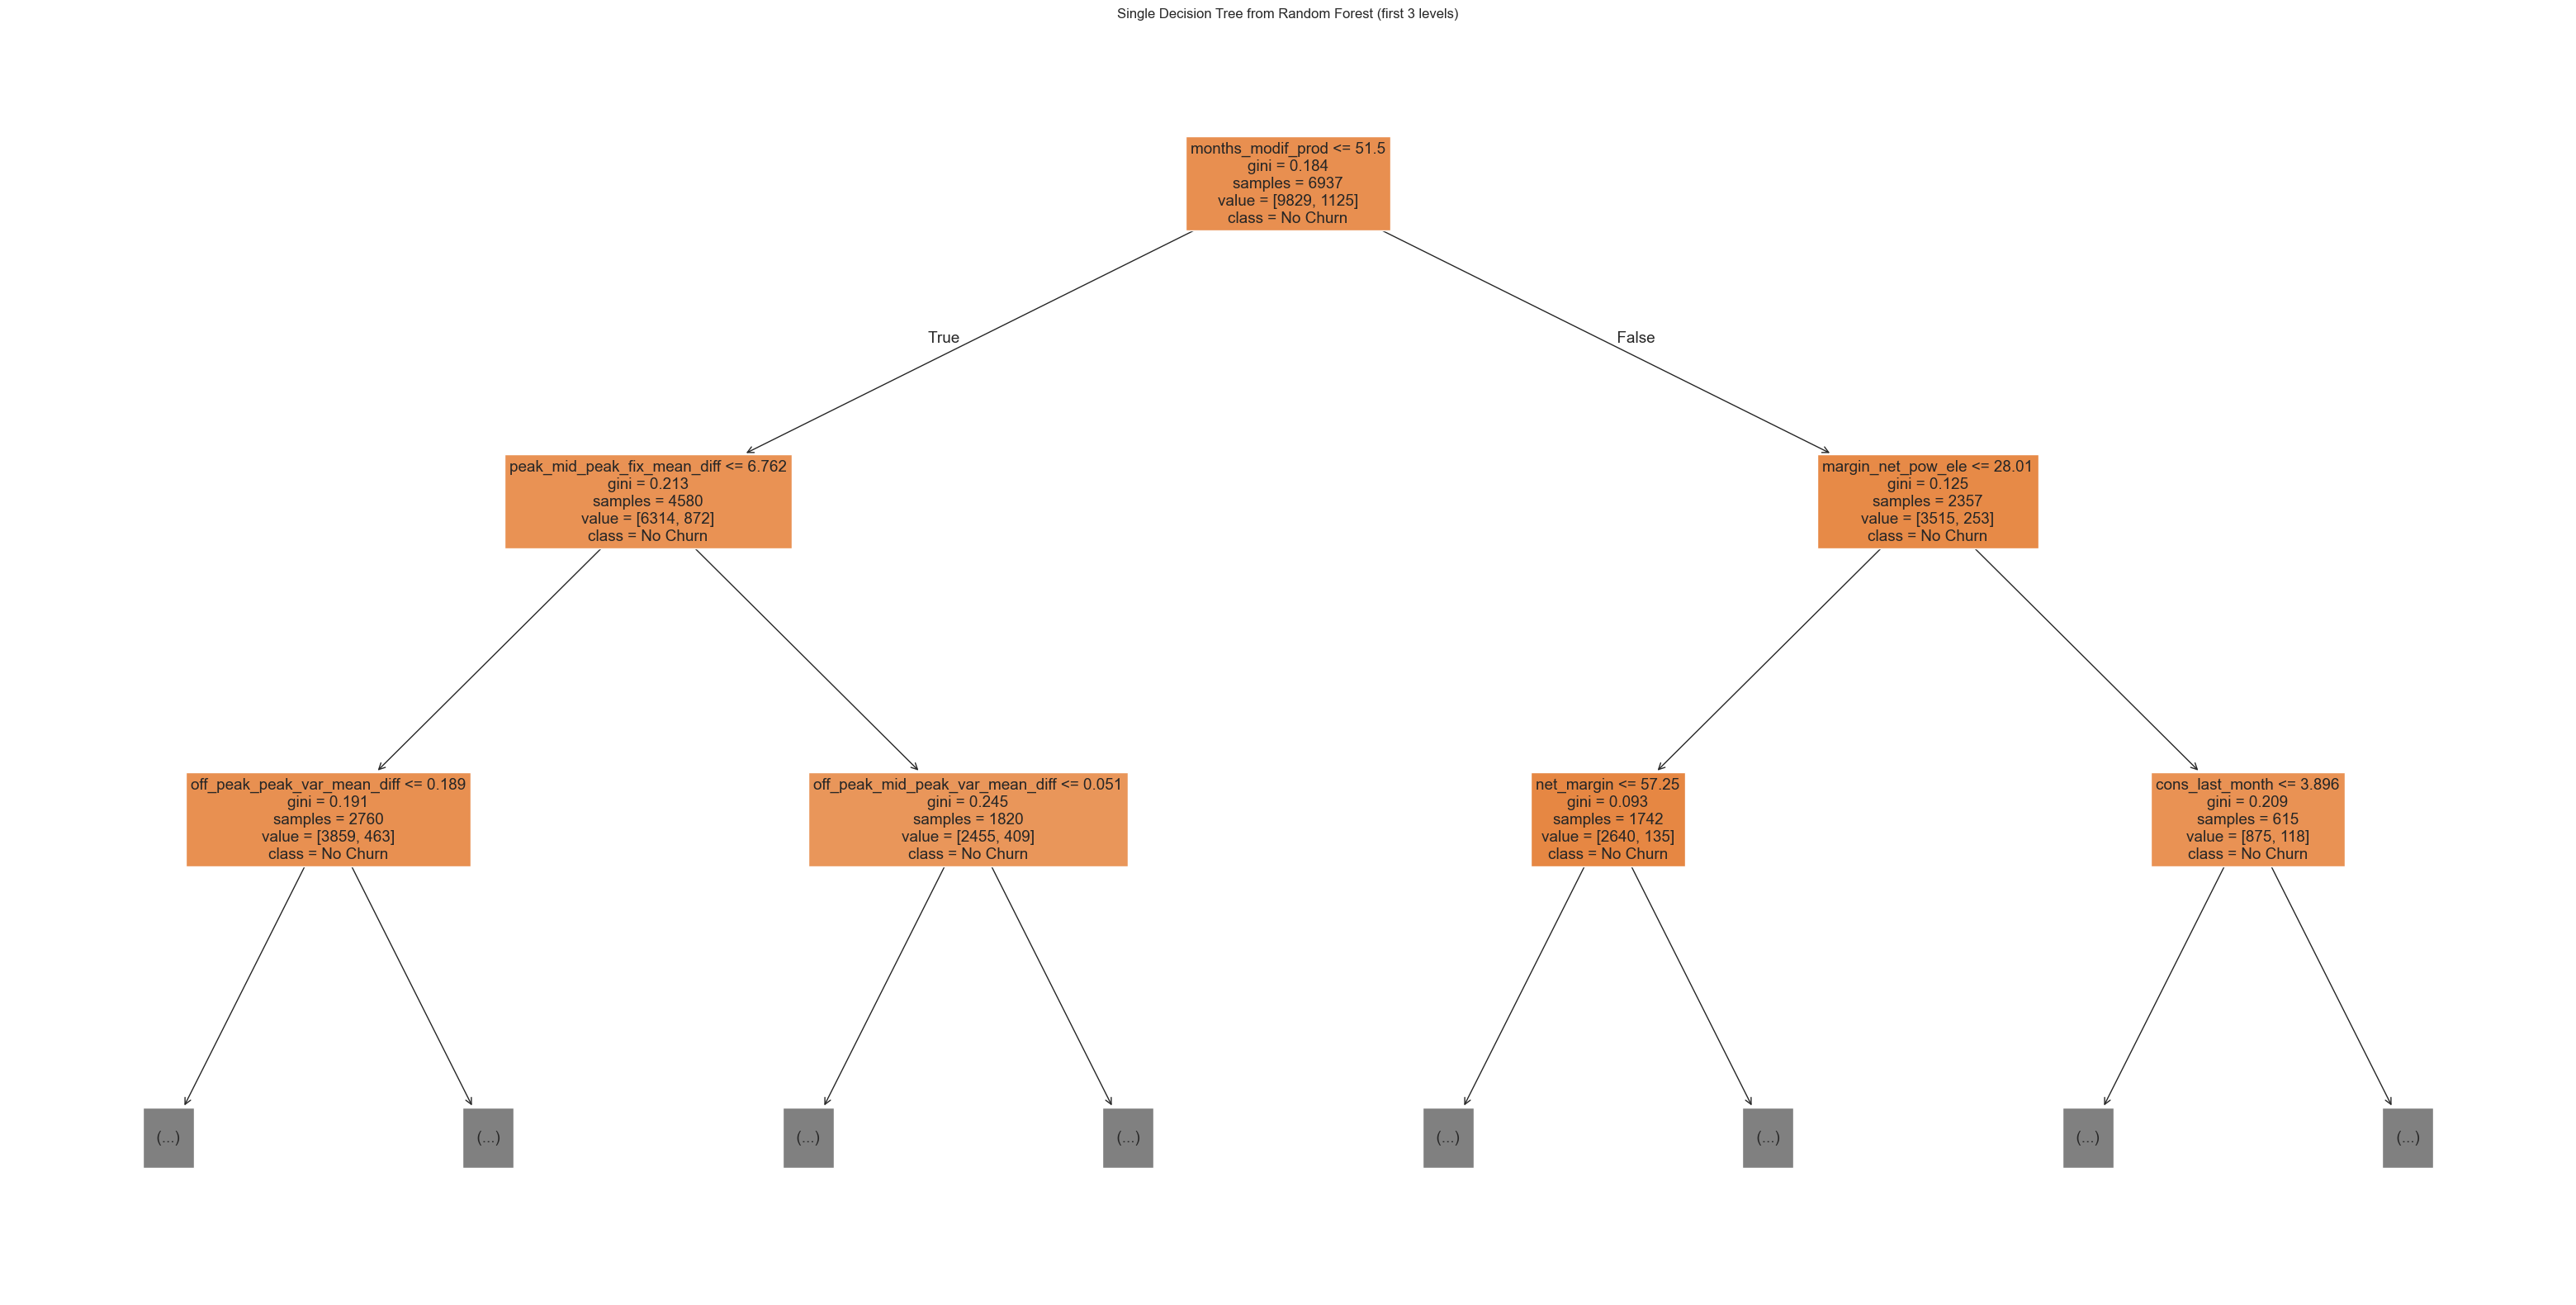

In [35]:
from sklearn.tree import plot_tree
plt.figure(figsize=(40, 20))
plot_tree(
    model_best.estimators_[0], 
    feature_names=X.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    max_depth=2
)
plt.title("Single Decision Tree from Random Forest (first 3 levels)")
plt.savefig('tree.png', dpi=300, bbox_inches='tight')
plt.show()

All nodes appear orange (No Churn) because class imbalance dominates every split. With only ~10% churners in the dataset, most branches end up majority non-churn regardless of the splitting rule. This single tree illustrates why recall for churners is low - the model rarely accumulates enough churners in a branch to flip the majority class prediction. The forest as a whole uses probability aggregation across 30 trees to partially compensate for this.